# Прогноз РТО магазинов X5 на март 2025

**Хакатон "Градиент роста"**

Прогноз розничного товарооборота (РТО) на март 2025 по историческим данным 2023-01 — 2025-02
(26 месяцев, 18 657 магазинов). Итоговое решение: один регуляризованный CatBoost + пост-обработка
прогноза (адаптивный клип относительно последнего известного значения).

**Результат на закрытом тесте: MAPE ≈ 9%, 82.69 баллов** по формуле `100 * ((100 - MAPE) / 100)²`.

Подробности пайплайна, метрики и обоснование решений — см. `README.md` в корне проекта.


In [ ]:
!python -V

Python 3.14.3


In [ ]:
!pip list

Package                 Version
----------------------- -----------
alembic                 1.18.5
appnope                 0.1.4
asttokens               3.0.1
catboost                1.2.10
colorlog                6.10.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.62.1
graphviz                0.21
ipykernel               7.2.0
ipython                 9.12.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
lightgbm                4.6.0
Mako                    1.3.12
MarkupSafe              3.0.3
matplotlib              3.10.8
matplotlib-inline       0.2.1
narwhals                2.21.2
nest-asyncio            1.6.0
numpy                   2.4.4
optuna                  4.9.0
packaging             

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import pickle
from pathlib import Path


In [ ]:
np.random.seed(2026)

## Анализ и подготовка данных для обучения

In [ ]:
df = pd.read_csv('train_2.csv')
df.head()

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74209339.11


In [277]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 485082 entries, 0 to 485081
Data columns (total 24 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     485082 non-null  int64  
 1   Год                                        485082 non-null  int64  
 2   Месяц                                      485082 non-null  int64  
 3   Среднее количество промо товаров в чеке    485082 non-null  float64
 4   Среднее количество товаров в чеке          485082 non-null  float64
 5   Среднее количество отмен                   485082 non-null  float64
 6   Рабочие часы в день                        485082 non-null  float64
 7   Дата открытия, категориальный              485082 non-null  str    
 8   Торговая площадь, категориальный           485082 non-null  str    
 9   Населенный пункт                           485082 non-null  str    
 10  Регион             

Шаг 1: Проверка и удаление дубликатов и пропусков

In [ ]:
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

full_duplicates = df.duplicated().sum()
print(f"Дубликатов строк: {full_duplicates}")

key_duplicates = df.duplicated(subset=['new_id', 'Год', 'Месяц']).sum()
print(f"Дубликатов по ключу (id+год+месяц): {key_duplicates}")

Series([], dtype: float64)
Дубликатов строк: 0
Дубликатов по ключу (id+год+месяц): 0


Шаг 2: Обработка периодов

In [ ]:
df['date'] = pd.to_datetime(df[['Год', 'Месяц']].assign(day=1).rename(
    columns={'Год': 'year', 'Месяц': 'month'}
))

df = df.sort_values(['new_id', 'date']).reset_index(drop=True)

print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Уникальных периодов: {df['date'].nunique()}")
print(f"Уникальных магазинов: {df['new_id'].nunique()}")

Диапазон дат: 2023-01-01 00:00:00 — 2025-02-01 00:00:00
Уникальных периодов: 26
Уникальных магазинов: 18657


In [ ]:
total_months = df['date'].nunique()
store_counts = df.groupby('new_id')['date'].count()

print(f"Ожидаемых периодов на магазин: {total_months}")
print(f"\nРаспределение фактических периодов:")
print(store_counts.describe())
print(f"\nМагазинов с полным рядом: {(store_counts == total_months).sum()}")
print(f"Магазинов с неполным рядом: {(store_counts < total_months).sum()}")

Ожидаемых периодов на магазин: 26

Распределение фактических периодов:
count    18657.0
mean        26.0
std          0.0
min         26.0
25%         26.0
50%         26.0
75%         26.0
max         26.0
Name: date, dtype: float64

Магазинов с полным рядом: 18657
Магазинов с неполным рядом: 0


In [ ]:
print(f"Строк: {len(df)}")
print(f"Магазинов: {df['new_id'].nunique()}")
print(f"Диапазон дат: Год {df['Год'].min()}–{df['Год'].max()}, месяцев {df['Месяц'].nunique()}")
print(f"Уникальных периодов (год+месяц): {df.groupby(['Год', 'Месяц']).ngroups}")

Строк: 485082
Магазинов: 18657
Диапазон дат: Год 2023–2025, месяцев 12
Уникальных периодов (год+месяц): 26


Шаг 3: Распределение РТО и выбросы

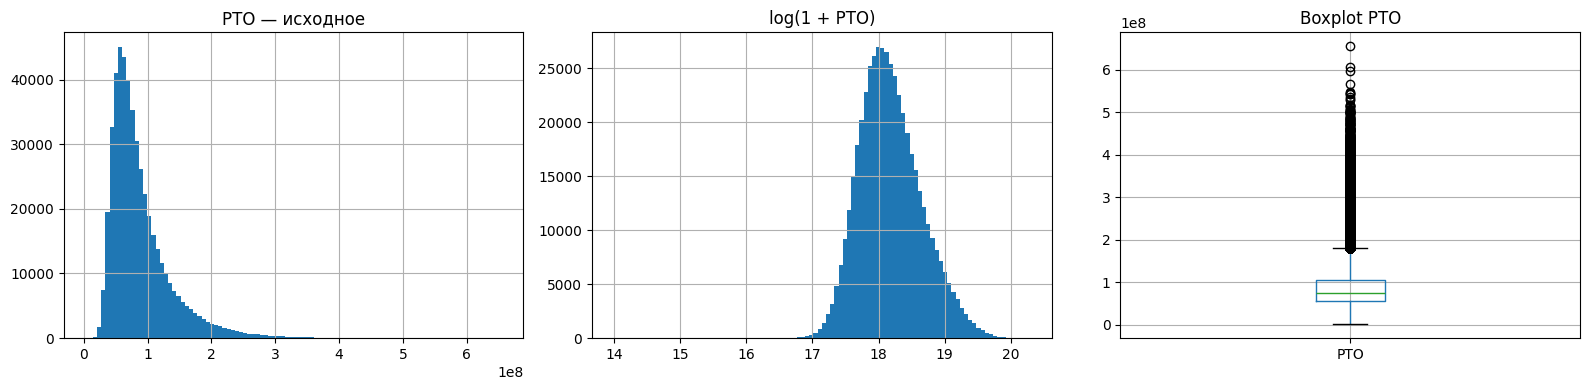

count    4.850820e+05
mean     8.853480e+07
std      4.824900e+07
min      1.179116e+06
1%       3.079648e+07
5%       3.920628e+07
25%      5.627279e+07
50%      7.521094e+07
75%      1.057677e+08
95%      1.850186e+08
99%      2.653948e+08
max      6.557204e+08
Name: РТО, dtype: float64

Skewness: 1.986
Отрицательных значений РТО: 0
Нулевых значений РТО: 0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['РТО'].hist(bins=100, ax=axes[0])
axes[0].set_title('РТО — исходное')

np.log1p(df['РТО']).hist(bins=100, ax=axes[1])
axes[1].set_title('log(1 + РТО)')

df.boxplot(column='РТО', ax=axes[2])
axes[2].set_title('Boxplot РТО')

plt.tight_layout()
plt.savefig('materials/target_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

print(df['РТО'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print(f"\nSkewness: {df['РТО'].skew():.3f}")
print(f"Отрицательных значений РТО: {(df['РТО'] < 0).sum()}")
print(f"Нулевых значений РТО: {(df['РТО'] == 0).sum()}")

In [ ]:
q1 = df.groupby('new_id')['РТО'].transform(lambda x: x.quantile(0.25))
q3 = df.groupby('new_id')['РТО'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

upper_outliers = (df['РТО'] > q3 + 3 * iqr).sum()
lower_outliers = (df['РТО'] < q1 - 3 * iqr).sum()

df['is_outlier'] = (df['РТО'] > q3 + 3 * iqr) | (df['РТО'] < q1 - 3 * iqr)

print(f"Выбросов найдено: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.2f}%)")
print(f"Выбросы сверху (слишком большие): {upper_outliers}")
print(f"Выбросы снизу (слишком маленькие): {lower_outliers}")

print("\nВыбросы по месяцам:")
print(df[df['is_outlier']].groupby('Месяц').size().sort_index())

Выбросов найдено: 1119 (0.23%)
Выбросы сверху (слишком большие): 662
Выбросы снизу (слишком маленькие): 457

Выбросы по месяцам:
Месяц
1     133
2     144
3      40
4      33
5      35
6      46
7      74
8      59
9      15
10     55
11     31
12    454
dtype: int64


In [ ]:
q1 = df.groupby('new_id')['РТО'].transform(lambda x: x.quantile(0.25))
q3 = df.groupby('new_id')['РТО'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

upper_mask = df['РТО'] > (q3 + 3 * iqr)
upper_outliers_df = df[upper_mask][['new_id', 'Год', 'Месяц', 'РТО']]

print(f"Верхних выбросов: {len(upper_outliers_df)}")
print(f"Уникальных магазинов: {upper_outliers_df['new_id'].nunique()}")
print("\nПо месяцам:")
print(upper_outliers_df.groupby('Месяц').size().sort_index())

Верхних выбросов: 662
Уникальных магазинов: 506

По месяцам:
Месяц
1      23
2      20
3      13
4       8
5      11
6      12
7      46
8      32
9       2
10     40
11     11
12    444
dtype: int64


In [ ]:
# Сезонность по месяцам + доля декабрьских выбросов
seas = df.groupby('Месяц')['РТО'].mean()
dec_share = (df[df['is_outlier']]['Месяц'] == 12).mean()

plt.figure(figsize=(8, 4))
colors = ['#C44E52' if m == 12 else '#4C72B0' for m in seas.index]
plt.bar(seas.index, seas.values, color=colors)
plt.title('Среднее РТО по месяцам (декабрь выделен)')
plt.xlabel('Месяц')
plt.ylabel('Среднее РТО')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('materials/seasonality_by_month.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Декабрь выше среднего по остальным месяцам на {seas[12] / seas.drop(12).mean() - 1:.1%}")
print(f"Доля всех IQR-выбросов, приходящихся на декабрь: {dec_share:.1%}")


In [ ]:
jf = df[df['Месяц'].isin([1, 2])].groupby('Год')['РТО'].mean()

plt.figure(figsize=(6, 4))
plt.plot(jf.index.astype(str), jf.values, marker='o', color='#4C72B0')
for x, y in zip(jf.index.astype(str), jf.values):
    plt.annotate(f'{y/1e6:.1f}M', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
plt.title('Среднее РТО (янв-фев) по годам')
plt.ylabel('Среднее РТО')
plt.tight_layout()
plt.savefig('materials/yoy_growth_janfeb.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Рост 2024 к 2023 (янв-фев): {jf[2024]/jf[2023]-1:.1%}")
print(f"Рост 2025 к 2024 (янв-фев): {jf[2025]/jf[2024]-1:.1%}")


In [ ]:
lower_mask = df['РТО'] < (q1 - 3 * iqr)
lower_outliers_df = df[lower_mask][['new_id', 'Год', 'Месяц', 'РТО']]

print(f"Нижних выбросов: {len(lower_outliers_df)}")
print(f"Уникальных магазинов с нижними выбросами: {lower_outliers_df['new_id'].nunique()}")
print("\nПо месяцам:")
print(lower_outliers_df.groupby('Месяц').size().sort_index())

Нижних выбросов: 457
Уникальных магазинов с нижними выбросами: 427

По месяцам:
Месяц
1     110
2     124
3      27
4      25
5      24
6      34
7      28
8      27
9      13
10     15
11     20
12     10
dtype: int64


In [ ]:
df = df.drop(columns=['is_outlier'])
df['РТО_log'] = np.log1p(df['РТО'])
df['is_december'] = (df['Месяц'] == 12).astype(int)

print(f"Skewness РТО:        {df['РТО'].skew():.3f}")
print(f"Skewness log(1+РТО): {df['РТО_log'].skew():.3f}")
print(f"Строк: {len(df)}, магазинов: {df['new_id'].nunique()}")
print(f"Пропусков: {df.isnull().sum().sum()}")
print(f"\nТекущие колонки:\n{df.columns.tolist()}")

Skewness РТО:        1.986
Skewness log(1+РТО): 0.374
Строк: 485082, магазинов: 18657
Пропусков: 0

Текущие колонки:
['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии', 'РТО', 'date', 'РТО_log', 'is_december']


Шаг 4: Лаговые признаки

In [ ]:
lag_periods = [1, 2, 3, 6, 12]

for lag in lag_periods:
    df[f'РТО_lag_{lag}'] = df.groupby('new_id')['РТО'].shift(lag)

In [ ]:
if 'df' in globals():
    df['trend_momentum'] = (df['РТО_lag_1'] / df['РТО_lag_2']) - 1
    df['trend_yearly'] = (df['РТО_lag_1'] / df['РТО_lag_12']) - 1
    df['trend_momentum'] = df['trend_momentum'].replace([np.inf, -np.inf], 0).fillna(0)
    df['trend_yearly'] = df['trend_yearly'].replace([np.inf, -np.inf], 0).fillna(0)
    print("Trend features 'trend_momentum' and 'trend_yearly' added.")
else:
    print("Variable 'df' not found. Please run the cell where 'df' is defined first.")

Trend features 'trend_momentum' and 'trend_yearly' added.


In [ ]:
print("До клипа:")
print(df[['trend_momentum', 'trend_yearly']].describe(percentiles=[.01, .05, .5, .95, .99]))

CLIP_LOW, CLIP_HIGH = -0.9, 3.0

df['trend_momentum_clipped'] = df['trend_momentum'].clip(CLIP_LOW, CLIP_HIGH)
df['trend_yearly_clipped'] = df['trend_yearly'].clip(CLIP_LOW, CLIP_HIGH)

n_clipped_mom = (df['trend_momentum'] != df['trend_momentum_clipped']).sum()
n_clipped_yr = (df['trend_yearly'] != df['trend_yearly_clipped']).sum()
print(f"\nОбрезано trend_momentum: {n_clipped_mom} строк")
print(f"Обрезано trend_yearly: {n_clipped_yr} строк")

До клипа:
       trend_momentum   trend_yearly
count   485082.000000  485082.000000
mean         0.017606       0.089609
std          0.174455       0.292341
min         -0.983895      -0.889968
1%          -0.227806      -0.184100
5%          -0.148402      -0.053076
50%          0.001551       0.000000
95%          0.185256       0.389583
99%          0.306394       0.607084
max         35.698959      74.503733

Обрезано trend_momentum: 91 строк
Обрезано trend_yearly: 136 строк


In [ ]:
windows = [3, 6, 12]

for w in windows:
    df[f'РТО_roll_mean_{w}'] = (
        df.groupby('new_id')['РТО']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )
    df[f'РТО_roll_std_{w}'] = (
        df.groupby('new_id')['РТО']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=2).std())
    )

In [ ]:
example_id = df['new_id'].iloc[0]
check = df[df['new_id'] == example_id][
    ['new_id', 'date', 'РТО', 'РТО_lag_1', 'РТО_lag_12', 'РТО_roll_mean_3']
].head(15)
print(check.to_string())

    new_id       date          РТО    РТО_lag_1   РТО_lag_12  РТО_roll_mean_3
0        0 2023-01-01  74914754.22          NaN          NaN              NaN
1        0 2023-02-01  69240001.40  74914754.22          NaN     7.491475e+07
2        0 2023-03-01  79905726.38  69240001.40          NaN     7.207738e+07
3        0 2023-04-01  78567643.63  79905726.38          NaN     7.468683e+07
4        0 2023-05-01  80856174.96  78567643.63          NaN     7.590446e+07
5        0 2023-06-01  74635062.29  80856174.96          NaN     7.977651e+07
6        0 2023-07-01  73579921.54  74635062.29          NaN     7.801963e+07
7        0 2023-08-01  71929528.80  73579921.54          NaN     7.635705e+07
8        0 2023-09-01  69963064.37  71929528.80          NaN     7.338150e+07
9        0 2023-10-01  76474955.25  69963064.37          NaN     7.182417e+07
10       0 2023-11-01  75835109.27  76474955.25          NaN     7.278918e+07
11       0 2023-12-01  84825173.40  75835109.27          NaN    

Шаг 5: Обработка и добавление признаков

In [292]:
# Календарные признаки
df['month_sin'] = np.sin(2 * np.pi * df['Месяц'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Месяц'] / 12)
df['is_december'] = (df['Месяц'] == 12).astype(int)

# Квартал
df['quarter'] = df['date'].dt.quarter
df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)
df['is_q4'] = (df['quarter'] == 4).astype(int)

# Год как нормализованный тренд
df['year_norm'] = (df['Год'] - df['Год'].min()) / (df['Год'].max() - df['Год'].min())

print("Календарные признаки созданы:")
print(df[['date', 'Месяц', 'month_sin', 'month_cos', 'quarter', 'year_norm',
          'is_q4', 'is_december']].drop_duplicates().sort_values('date').to_string(index=False))

Календарные признаки созданы:
      date  Месяц     month_sin     month_cos  quarter  year_norm  is_q4  is_december
2023-01-01      1  5.000000e-01  8.660254e-01        1        0.0      0            0
2023-02-01      2  8.660254e-01  5.000000e-01        1        0.0      0            0
2023-03-01      3  1.000000e+00  6.123234e-17        1        0.0      0            0
2023-04-01      4  8.660254e-01 -5.000000e-01        2        0.0      0            0
2023-05-01      5  5.000000e-01 -8.660254e-01        2        0.0      0            0
2023-06-01      6  1.224647e-16 -1.000000e+00        2        0.0      0            0
2023-07-01      7 -5.000000e-01 -8.660254e-01        3        0.0      0            0
2023-08-01      8 -8.660254e-01 -5.000000e-01        3        0.0      0            0
2023-09-01      9 -1.000000e+00 -1.836970e-16        3        0.0      0            0
2023-10-01     10 -8.660254e-01  5.000000e-01        4        0.0      1            0
2023-11-01     11 -5.000

In [ ]:
# Производные признаки из характеристик магазина
df['доля_пятерочек'] = df['Пятерочки (500 м)'] / (df['Продуктовые магазины (500 м)'] + 1)
df['инфра_индекс'] = (
    df['Медицинские уч. и аптеки (300 м)'] +
    df['Школы (300 м)'] +
    df['Остановки (300 м)']
)

print("Производные признаки:")
print(df[['доля_пятерочек', 'инфра_индекс']].describe())

Производные признаки:
       доля_пятерочек   инфра_индекс
count   485082.000000  485082.000000
mean         0.150072       3.759608
std          0.176702       4.053982
min          0.000000       0.000000
25%          0.000000       1.000000
50%          0.111111       3.000000
75%          0.250000       6.000000
max          1.333333      41.000000


Обработка категориальных признаков

In [ ]:
opening_order = {
    'Новый': 0,
    'Средний по возрасту': 1,
    'Открыт давно': 2
}
df['Дата открытия, enc'] = df['Дата открытия, категориальный'].map(opening_order)

area_order = {
    'Маленький': 0,
    'Средний': 1,
    'Большой': 2,
    'Очень большой': 3
}
df['Торговая площадь, enc'] = df['Торговая площадь, категориальный'].map(area_order)

print(f"NaN Дата открытия: {df['Дата открытия, enc'].isnull().sum()}")
print(f"NaN Торговая площадь: {df['Торговая площадь, enc'].isnull().sum()}")

NaN Дата открытия: 0
NaN Торговая площадь: 0


In [295]:
# для признаков с большим количеством уникальных значений используем энкодеры
le_region = LabelEncoder()
le_city = LabelEncoder()

df['Регион_enc'] = le_region.fit_transform(df['Регион'].astype(str))
df['Город_enc'] = le_city.fit_transform(df['Населенный пункт'].astype(str))

with open('le_region.pkl', 'wb') as f:
    pickle.dump(le_region, f)
with open('le_city.pkl', 'wb') as f:
    pickle.dump(le_city, f)

print(f"Регион_enc — уникальных: {df['Регион_enc'].nunique()}")
print(f"Город_enc — уникальных: {df['Город_enc'].nunique()}")
print(f"NaN: {df[['Регион_enc', 'Город_enc']].isnull().sum().sum()}")

Регион_enc — уникальных: 67
Город_enc — уникальных: 3270
NaN: 0


In [296]:
# Итог (смотрим все созданные признаки)
enc_cols = ['Дата открытия, enc', 'Торговая площадь, enc', 'Регион_enc', 'Город_enc']
print("Энкодинг категориальных признаков")
print(df[enc_cols].describe())

print(f"\nВсего колонок: {len(df.columns)}")
print(f"Пропусков: {df.isnull().sum().sum()}")

Энкодинг категориальных признаков
       Дата открытия, enc  Торговая площадь, enc     Регион_enc      Город_enc
count       485082.000000          485082.000000  485082.000000  485082.000000
mean             0.814976               1.052420      35.823766    1700.295171
std              0.498876               0.718769      16.679524     878.682607
min              0.000000               0.000000       0.000000       0.000000
25%              1.000000               1.000000      24.000000    1015.000000
50%              1.000000               1.000000      35.000000    1704.000000
75%              1.000000               1.000000      48.000000    2416.000000
max              2.000000               3.000000      66.000000    3269.000000

Всего колонок: 55
Пропусков: 615681


 Шаг 6: Проверка связи признаков с РТО и между собой

In [297]:
# Корреляция всех признаков с РТО
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Убираем не несущие смысла для модели
exclude = ['new_id', 'Год', 'Месяц', 'РТО_log', 'quarter']

corr_cols = [c for c in numeric_cols if c not in exclude]

# Используем корреляцию Спирмена
corr_with_target = df[corr_cols].corrwith(df['РТО'], method='spearman').sort_values(ascending=False)

print("Корреляция признаков с РТО (Спирмен):")
print(corr_with_target.to_string())

Корреляция признаков с РТО (Спирмен):
РТО                                          1.000000
РТО_lag_1                                    0.967618
РТО_roll_mean_3                              0.962161
РТО_roll_mean_12                             0.957283
РТО_roll_mean_6                              0.953021
РТО_lag_12                                   0.950580
РТО_lag_2                                    0.948441
РТО_lag_3                                    0.931878
РТО_lag_6                                    0.897837
РТО_roll_std_12                              0.675414
Среднее количество отмен                     0.638716
РТО_roll_std_6                               0.624184
Количество касс                              0.562109
РТО_roll_std_3                               0.511354
Торговая площадь, enc                        0.449889
Среднее количество товаров в чеке            0.409167
Среднее количество промо товаров в чеке      0.202379
инфра_индекс                                

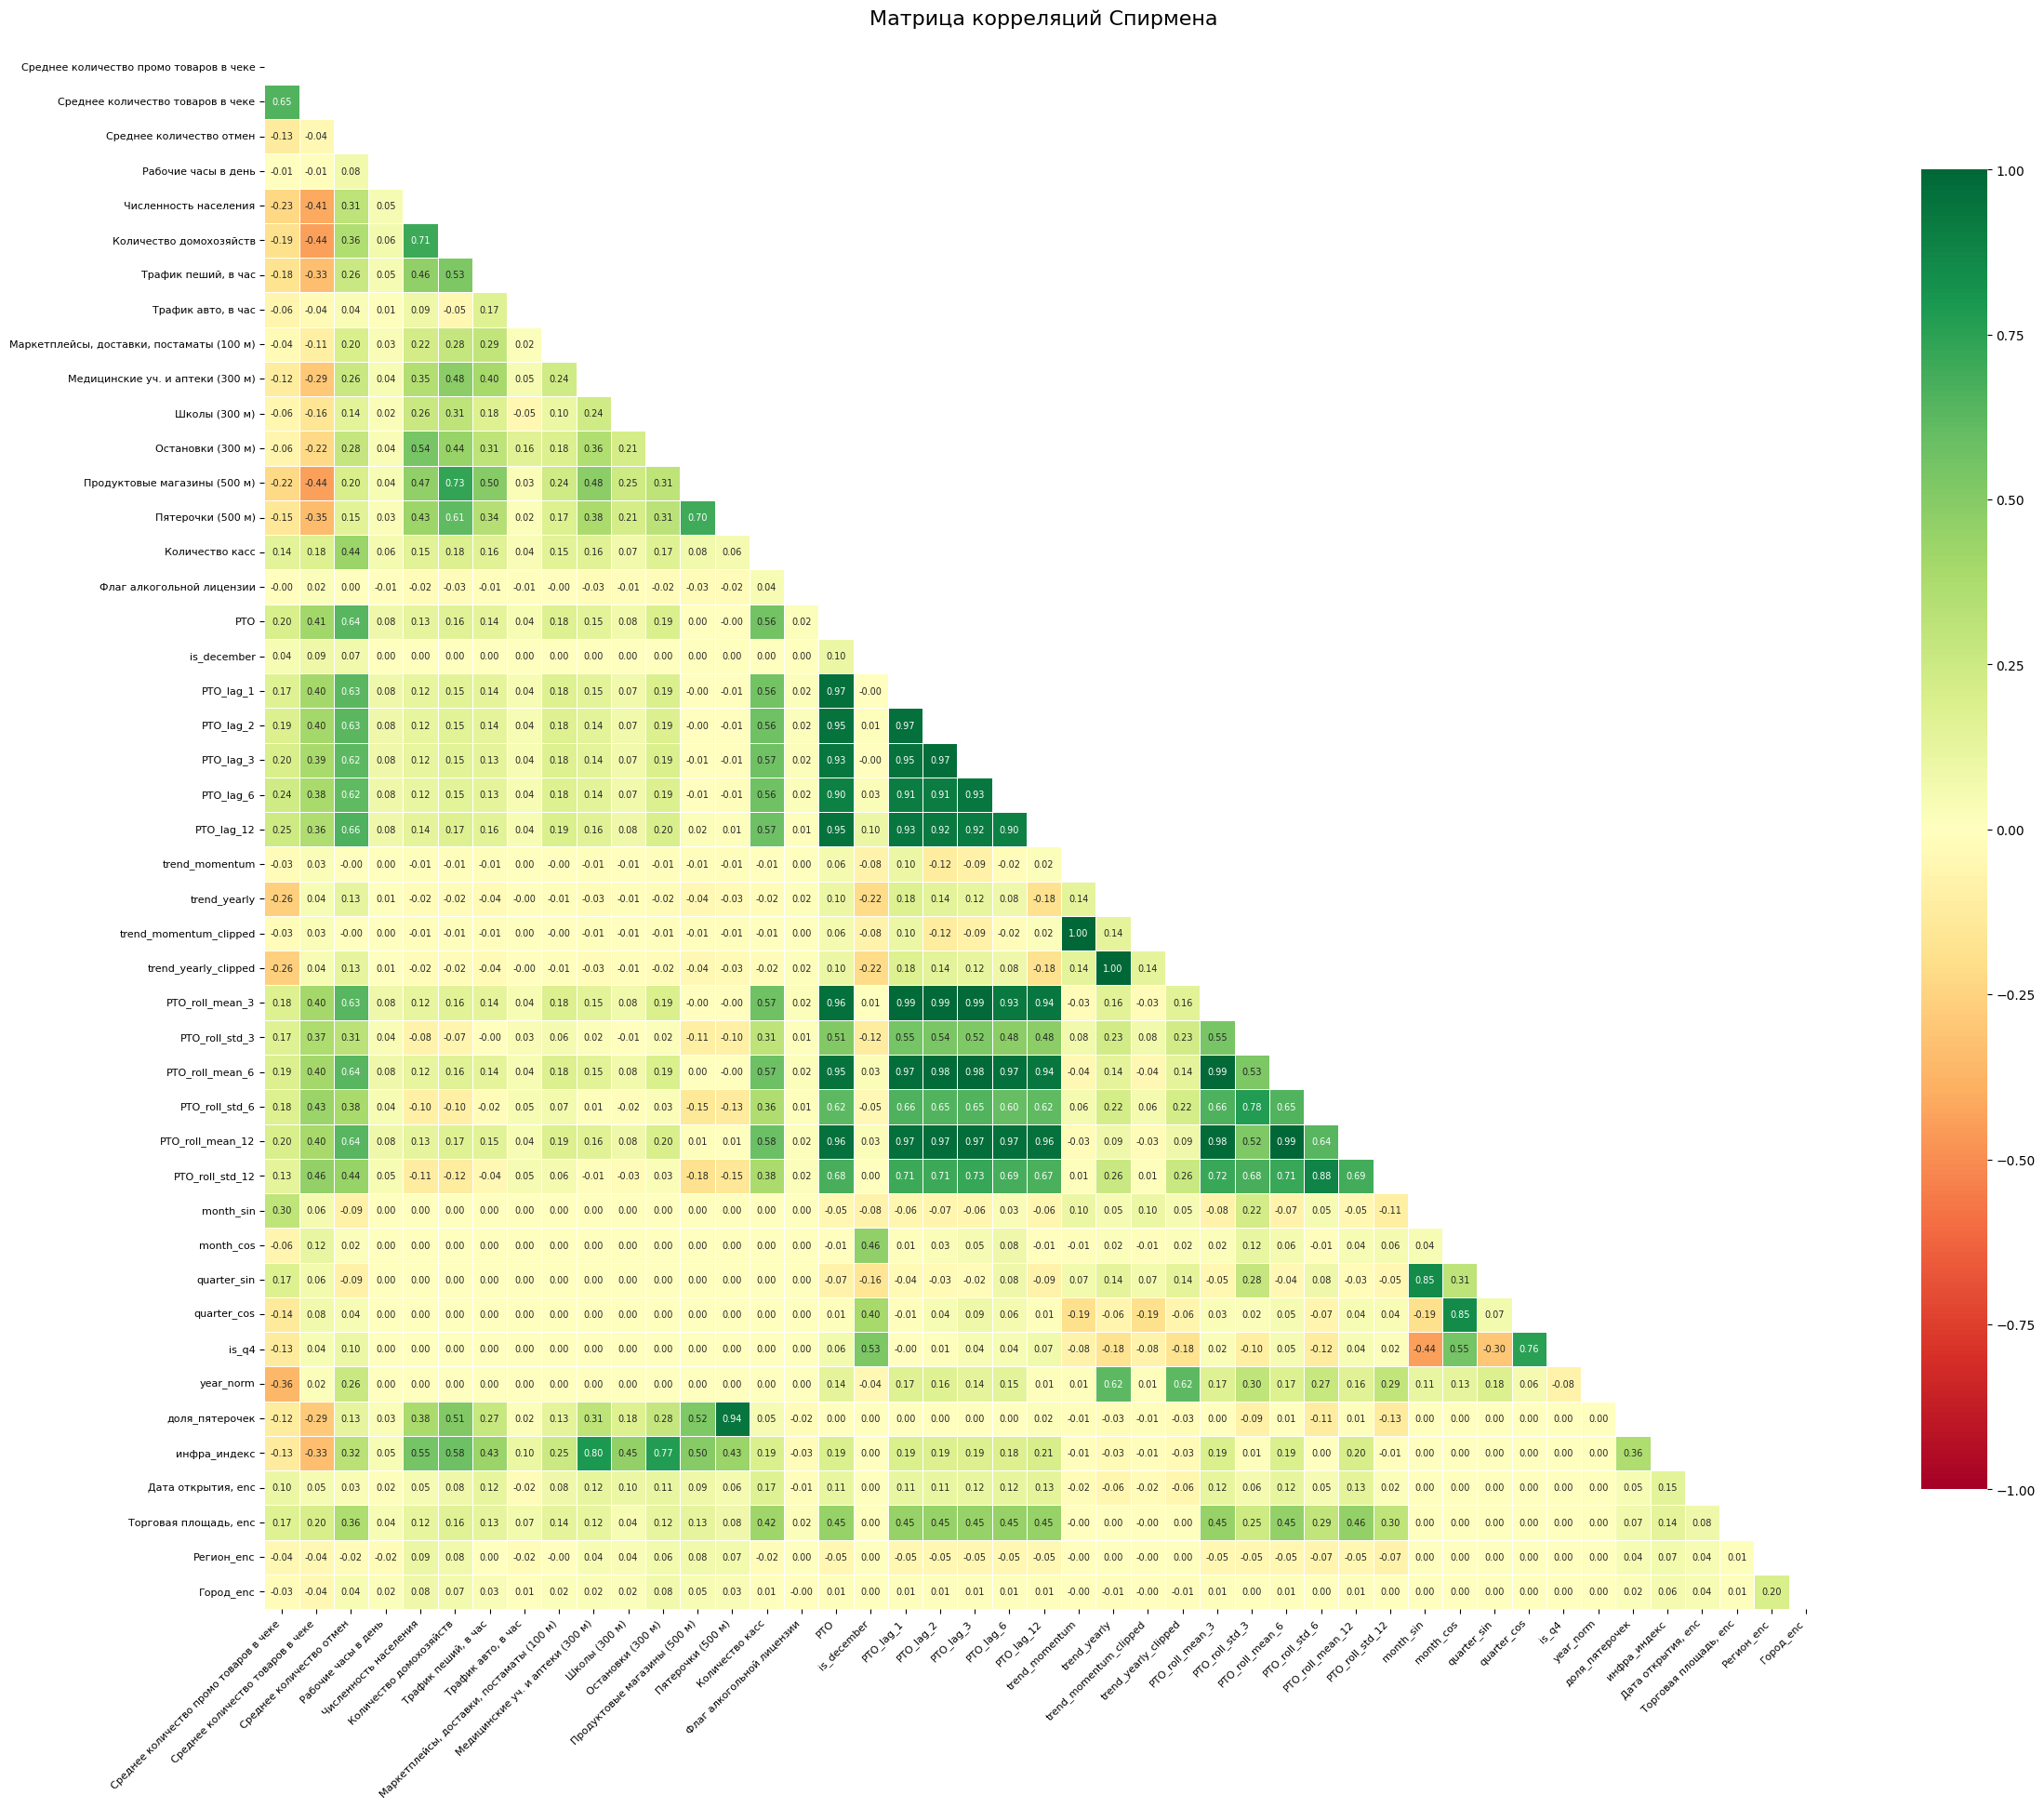

In [ ]:
# матрица корреляций
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['new_id', 'Год', 'Месяц', 'РТО_log', 'quarter']
corr_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(24, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
plt.title('Матрица корреляций Спирмена', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('materials/full_correlation_matrix.png', dpi=110, bbox_inches='tight')
plt.show()

In [299]:
# Пары с высокой взаимной корреляцией (> 0.85)
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.85:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            corr_rto_i = corr_matrix.loc[col_i, 'РТО'] if 'РТО' in corr_matrix.columns else None
            corr_rto_j = corr_matrix.loc[col_j, 'РТО'] if 'РТО' in corr_matrix.columns else None
            high_corr_pairs.append({
                'признак_1': col_i,
                'признак_2': col_j,
                'корреляция_друг_с_другом': round(val, 3),
                'корр_с_РТО_1': round(corr_rto_i, 3) if corr_rto_i else None,
                'корр_с_РТО_2': round(corr_rto_j if corr_rto_j else 0, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('корреляция_друг_с_другом', ascending=False)
print(f"Пар с корреляцией > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Пар с корреляцией > 0.85: 40
        признак_1              признак_2  корреляция_друг_с_другом  корр_с_РТО_1  корр_с_РТО_2
   trend_momentum trend_momentum_clipped                     1.000         0.056         0.056
     trend_yearly   trend_yearly_clipped                     1.000         0.096         0.096
  РТО_roll_mean_6       РТО_roll_mean_12                     0.994         0.953         0.957
  РТО_roll_mean_3        РТО_roll_mean_6                     0.991         0.962         0.953
        РТО_lag_2        РТО_roll_mean_3                     0.991         0.948         0.962
        РТО_lag_1        РТО_roll_mean_3                     0.986         0.968         0.962
        РТО_lag_3        РТО_roll_mean_3                     0.986         0.932         0.962
        РТО_lag_3        РТО_roll_mean_6                     0.985         0.932         0.953
  РТО_roll_mean_3       РТО_roll_mean_12                     0.984         0.962         0.957
        РТО_lag_2    

Чистим лишние признаки, готовим данные для модели

In [ ]:
# Убираем мультиколлинеарные признаки
cols_to_drop = [
    'РТО_roll_mean_6',
    'РТО_roll_mean_12',
    'Пятерочки (500 м)',
]

df = df.drop(columns=cols_to_drop)
print(f"Удалено колонок: {len(cols_to_drop)}")
print(f"Осталось колонок: {len(df.columns)}")

Удалено колонок: 3
Осталось колонок: 52


In [301]:
# Убираем лишние колонки
service_cols = [
    'Дата открытия, категориальный',     # заменена на Дата открытия, enc
    'Торговая площадь, категориальный',  # заменена на Торговая площадь, enc
    'Населенный пункт',                  # заменена на Город_enc
    'Регион',                            # заменена на Регион_enc
]

df = df.drop(columns=service_cols)

print(f"Колонок осталось: {len(df.columns)}")
print(f"Строк: {len(df)}")
print(f"Пропусков: {df.isnull().sum().sum()}")

Колонок осталось: 48
Строк: 485082
Пропусков: 578367


Шаг 7: Сплит

In [ ]:
sorted_dates = sorted(df['date'].unique())
train = df[df['date'].isin(sorted_dates[:-3])].copy()
test  = df[df['date'].isin(sorted_dates[-3:])].copy()

print(f"Train: {train['date'].min().strftime('%Y-%m')} — {train['date'].max().strftime('%Y-%m')}, {len(train):,} строк")
print(f"Test:  {test['date'].min().strftime('%Y-%m')} — {test['date'].max().strftime('%Y-%m')}, {len(test):,} строк")

Train: 2023-01 — 2024-11, 429,111 строк
Test:  2024-12 — 2025-02, 55,971 строк


In [ ]:
for col, name in [('Регион_enc', 'Регион_target_enc'), ('Город_enc', 'Город_target_enc')]:
    enc = train.groupby(col)['РТО'].mean().rename(name)
    train[name] = train[col].map(enc)
    test[name]  = test[col].map(enc)

print(f"NaN target enc в test: {test[['Регион_target_enc', 'Город_target_enc']].isnull().sum().sum()}")

NaN target enc в test: 0


In [304]:
# Удаляем date
train = train.drop(columns=['date'])
test  = test.drop(columns=['date'])

# Убираем строки с NaN в lag_12 только из train
train = train.dropna(subset=['РТО_lag_12']).reset_index(drop=True)

In [ ]:
feature_cols = [c for c in train.columns if c not in ['new_id', 'РТО', 'РТО_log', 'Регион_enc', 'Город_enc']]

print(f"Признаков: {len(feature_cols)}")
print(f"Train: {len(train):,} строк, пропусков: {train[feature_cols].isnull().sum().sum()}")
print(f"Test:  {len(test):,} строк, пропусков: {test[feature_cols].isnull().sum().sum()}")
print("\nПризнаки:")
for c in feature_cols:
    print(f"  {c}")


Признаков: 44
Train: 205,227 строк, пропусков: 0
Test:  55,971 строк, пропусков: 0

Признаки:
  Год
  Месяц
  Среднее количество промо товаров в чеке
  Среднее количество товаров в чеке
  Среднее количество отмен
  Рабочие часы в день
  Численность населения
  Количество домохозяйств
  Трафик пеший, в час
  Трафик авто, в час
  Маркетплейсы, доставки, постаматы (100 м)
  Медицинские уч. и аптеки (300 м)
  Школы (300 м)
  Остановки (300 м)
  Продуктовые магазины (500 м)
  Количество касс
  Флаг алкогольной лицензии
  is_december
  РТО_lag_1
  РТО_lag_2
  РТО_lag_3
  РТО_lag_6
  РТО_lag_12
  trend_momentum
  trend_yearly
  trend_momentum_clipped
  trend_yearly_clipped
  РТО_roll_mean_3
  РТО_roll_std_3
  РТО_roll_std_6
  РТО_roll_std_12
  month_sin
  month_cos
  quarter
  quarter_sin
  quarter_cos
  is_q4
  year_norm
  доля_пятерочек
  инфра_индекс
  Дата открытия, enc
  Торговая площадь, enc
  Регион_target_enc
  Город_target_enc


In [306]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error

y_train = np.log1p(train['РТО'])
y_test = np.log1p(test['РТО'])

X_train = train[feature_cols]
X_test = test[feature_cols]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (205227, 44), Test: (55971, 44)


In [ ]:
cb_single = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.01,
    depth=8,
    l2_leaf_reg=5,
    loss_function='RMSE',
    eval_metric='MAPE',
    random_seed=2026,
    early_stopping_rounds=150,
    verbose=300
)

cb_single.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

single_preds = np.expm1(cb_single.predict(X_test))
mape_single = mean_absolute_percentage_error(np.expm1(y_test), single_preds) * 100
print(f"MAPE (holdout): {mape_single:.2f}%")


0:	learn: 0.0200420	test: 0.0199772	best: 0.0199772 (0)	total: 17.7ms	remaining: 53s
300:	learn: 0.0031143	test: 0.0045303	best: 0.0045303 (300)	total: 3.84s	remaining: 34.4s
600:	learn: 0.0023949	test: 0.0043391	best: 0.0042822 (463)	total: 7.24s	remaining: 28.9s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.004282237868
bestIteration = 463

Shrink model to first 464 iterations.
MAPE (holdout): 7.74%


In [ ]:
volatility = (test['РТО_roll_std_3'] / (test['РТО_roll_mean_3'] + 1)).clip(0.05, 1.0)
band = 1 + volatility * 2

lower_bound = test['РТО_lag_1'].values / band.values
upper_bound = test['РТО_lag_1'].values * band.values
single_preds_clipped = np.clip(single_preds, lower_bound, upper_bound)

mape_clipped = mean_absolute_percentage_error(np.expm1(y_test), single_preds_clipped) * 100
n_clipped = ((single_preds < lower_bound) | (single_preds > upper_bound)).sum()

print(f"MAPE (holdout, с адаптивным клипом): {mape_clipped:.2f}%")
print(f"Прогнозов под клипом: {n_clipped} из {len(single_preds)}")


MAPE (holdout, с адаптивным клипом): 7.67%
Прогнозов под клипом: 6776 из 55971


## Прогноз на март 2025 и сохранение сабмита

In [ ]:
unique_store_ids = df['new_id'].unique()
march_data = []
for store_id in unique_store_ids:
    store_last = df[df['new_id'] == store_id].tail(1).copy()
    store_last['Год'] = 2025
    store_last['Месяц'] = 3
    store_last['date'] = pd.to_datetime("2025-03-01")
    store_last['РТО'] = np.nan
    march_data.append(store_last)

march_df_base = pd.concat(march_data, ignore_index=True)
df_combined = pd.concat([df, march_df_base], ignore_index=True).sort_values(['new_id', 'date']).reset_index(drop=True)

for lag in [1, 2, 3, 6, 12]:
    df_combined[f'РТО_lag_{lag}'] = df_combined.groupby('new_id')['РТО'].shift(lag)

CLIP_LOW, CLIP_HIGH = -0.9, 3.0

df_combined['РТО_roll_mean_3'] = df_combined.groupby('new_id')['РТО'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_combined['РТО_roll_std_3'] = df_combined.groupby('new_id')['РТО'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
df_combined['trend_momentum'] = ((df_combined['РТО_lag_1'] / df_combined['РТО_lag_2']) - 1).clip(CLIP_LOW, CLIP_HIGH)
df_combined['trend_yearly'] = ((df_combined['РТО_lag_1'] / df_combined['РТО_lag_12']) - 1).clip(CLIP_LOW, CLIP_HIGH)
df_combined['trend_momentum'] = df_combined['trend_momentum'].replace([np.inf, -np.inf], 0).fillna(0)
df_combined['trend_yearly'] = df_combined['trend_yearly'].replace([np.inf, -np.inf], 0).fillna(0)
df_combined['year_norm'] = (df_combined['Год'] - df_combined['Год'].min()) / (df_combined['Год'].max() - df_combined['Год'].min())

march_df = df_combined[(df_combined['Год'] == 2025) & (df_combined['Месяц'] == 3)].copy()

region_enc = train.groupby('Регион_enc')['РТО'].mean()
city_enc = train.groupby('Город_enc')['РТО'].mean()
march_df['Регион_target_enc'] = march_df['Регион_enc'].map(region_enc)
march_df['Город_target_enc'] = march_df['Город_enc'].map(city_enc)

march_features = march_df[feature_cols]
march_preds = np.expm1(cb_single.predict(march_features))

volatility_march = (march_df['РТО_roll_std_3'] / (march_df['РТО_roll_mean_3'] + 1)).clip(0.05, 1.0)
band_march = 1 + volatility_march * 2

lower_bound_march = march_df['РТО_lag_1'].values / band_march.values
upper_bound_march = march_df['РТО_lag_1'].values * band_march.values
march_preds_clipped = np.clip(march_preds, lower_bound_march, upper_bound_march)

submission = pd.DataFrame({
    'new_id': march_df_base['new_id'].values,
    'rto': march_preds_clipped
})
assert len(submission) == df['new_id'].nunique(), "строк должно быть ровно по числу магазинов"
assert submission['rto'].isna().sum() == 0, "не должно быть NaN"

submission.to_csv('submisson.csv', index=False)
print("Файл 'submisson.csv' создан.")
print(f"Строк: {len(submission)}, уникальных new_id: {submission['new_id'].nunique()}, NaN: {submission['rto'].isna().sum()}")
display(submission.head())


Файл 'Stacking_res_single.csv' создан.
Строк: 18657, уникальных new_id: 18657, NaN: 0


,new_id,rto
0,0,8.608995e+07
1,1,4.181914e+07
2,2,8.292158e+07
3,3,6.355939e+07
4,4,7.728885e+07
